In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
plt.figure(figsize=(2, 2))

<Figure size 200x200 with 0 Axes>

<Figure size 200x200 with 0 Axes>

## 模糊匹配

- TM_SODIFF:计算平方不同，计算出来的值越小，越相关
- TM_CCORR:计算相关性，计算出来的值越大，越相关
- TM_CCOEFF:计算相关系数，计算出来的值越大，越相关
- TM_SQDIFF NORMED:计算归一化平方不同，计算出来的值越接近0，越相关
- TM_CCORR NORMED:计算归一化相关性，计算出来的值越接近1，越相关
- TM_CCOEFF_NORMED:计算归一化相关系数，计算出来的值越接近1，越相关

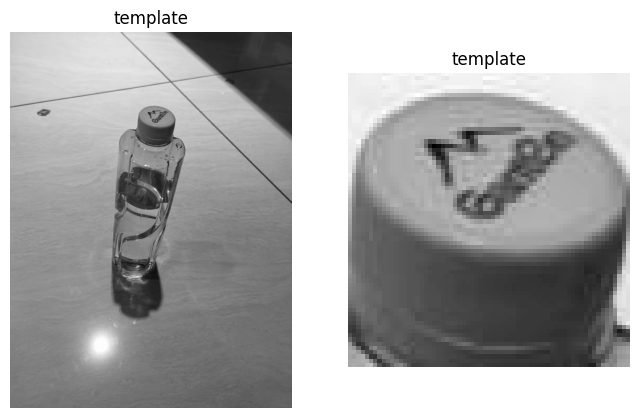

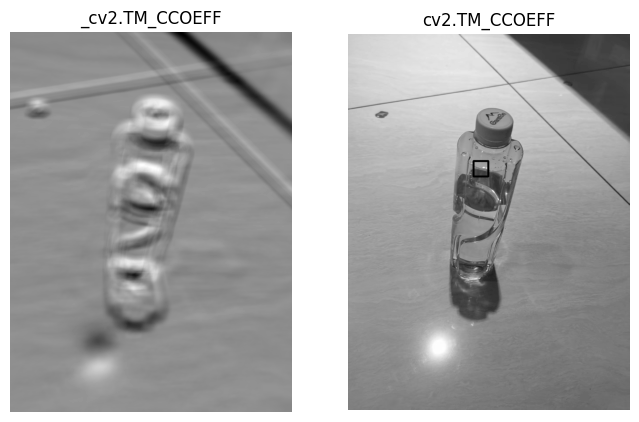

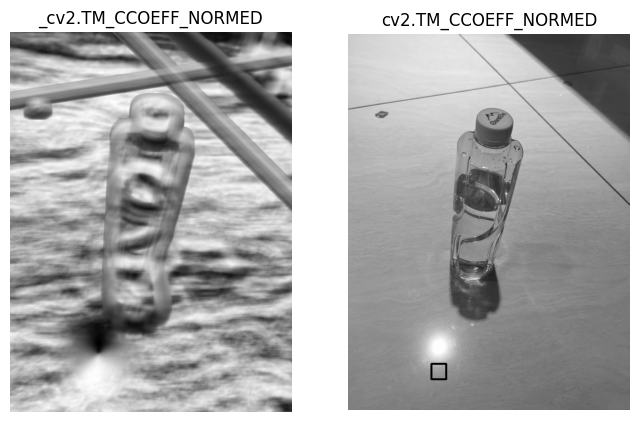

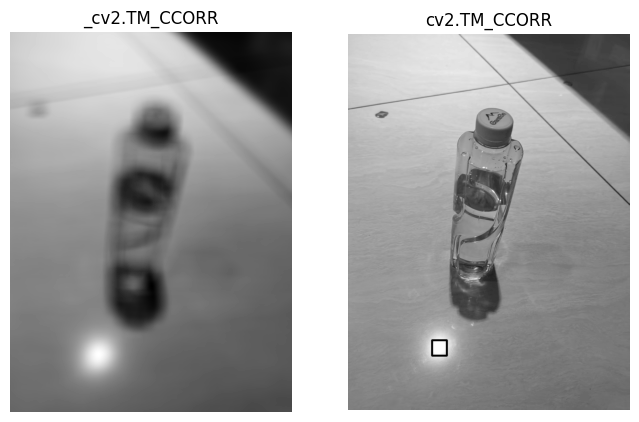

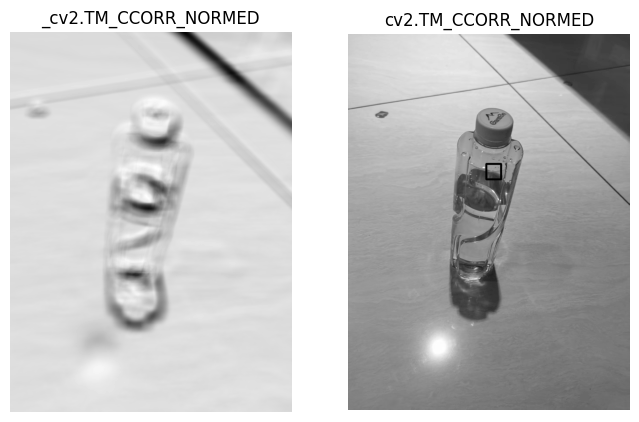

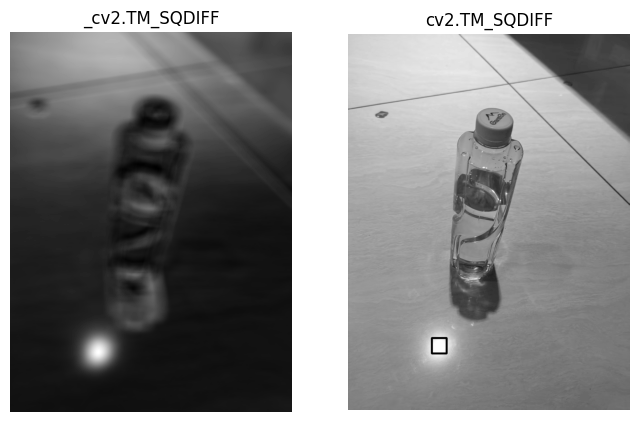

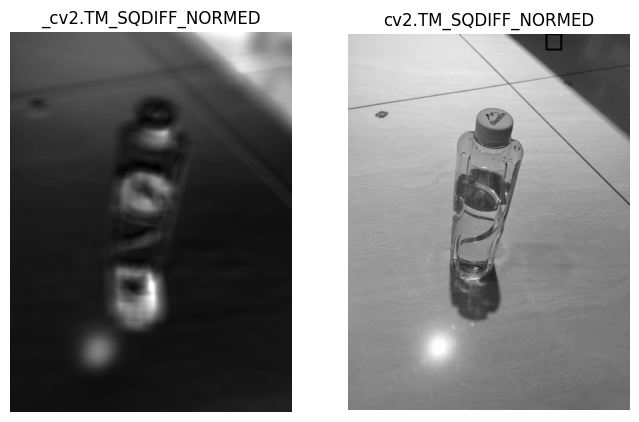

In [28]:
img = cv2.imread('./assets/1.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
template = cv2.imread('./assets/p.jpg')
template = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)
h, w = template.shape[:2]

methods = ['cv2.TM_CCOEFF', 'cv2.TM_CCOEFF_NORMED', 'cv2.TM_CCORR', 'cv2.TM_CCORR_NORMED'
    , 'cv2.TM_SQDIFF', 'cv2.TM_SQDIFF_NORMED']

plt.figure(figsize=(8, 8))
plt.subplot(121), plt.imshow(img, cmap='gray'), plt.title("template"), plt.axis('off')
plt.subplot(122), plt.imshow(template, cmap='gray'), plt.title("template"), plt.axis('off')
plt.show()
for meth in methods:
    img2 = img.copy()

    plt.figure(figsize=(8, 8))
    method = eval(meth)
    res = cv2.matchTemplate(img, template, method)
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

    if method in ['cv2.TM_SQDIFF', 'cv2.TM_SQDIFF']:
        top_left = min_loc
    else:
        top_left = max_loc
    bottom_right = (top_left[0] + w, top_left[1] + h)

    plt.subplot(121), plt.imshow(res, cmap='gray'), plt.title('_'+meth), plt.axis('off')
    # 画矩形
    cv2.rectangle(img2, top_left, bottom_right, 0, 8)
    plt.subplot(122), plt.imshow(img2, cmap='gray'), plt.title(meth), plt.axis('off')
    plt.show()